# India Air Quality & Crop Production - EDA Lab
### Lab 1 : Data Preprocessing and Visualisation

**Datasets:** `city_day.csv` (air quality - 29,531 rows) | `crop_production.csv` (crop production - 246,091 rows)

---
## Task 1 - First Look at the Data

Load both files and inspect shape, column types, statistics, and missing values.

In [115]:
import pandas as pd
import matplotlib.pyplot as plt

aqi  = pd.read_csv("city_day.csv")
crop = pd.read_csv("crop_production.csv")

print("AQI  shape :", aqi.shape)
print("Crop shape :", crop.shape)

AQI  shape : (29531, 16)
Crop shape : (246091, 7)


In [116]:
print("-- AQI : first 5 rows --")
print(aqi.head().to_string())

-- AQI : first 5 rows --
        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2      O3  Benzene  Toluene  Xylene  AQI AQI_Bucket
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64  133.36     0.00     0.02    0.00  NaN        NaN
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   34.06     3.68     5.50    3.77  NaN        NaN
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   30.70     6.80    16.40    2.25  NaN        NaN
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   36.08     4.43    10.14    1.00  NaN        NaN
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   39.31     7.01    18.89    2.78  NaN        NaN


In [117]:
print("-- AQI : column info --")
aqi.info()

-- AQI : column info --
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [118]:
print("-- AQI : statistics --")
print(aqi.describe().round(2).to_string())

-- AQI : statistics --
          PM2.5      PM10        NO       NO2       NOx       NH3        CO       SO2        O3   Benzene   Toluene    Xylene       AQI
count  24933.00  18391.00  25949.00  25946.00  25346.00  19203.00  27472.00  25677.00  25509.00  23908.00  21490.00  11422.00  24850.00
mean      67.45    118.13     17.57     28.56     32.31     23.48      2.25     14.53     34.49      3.28      8.70      3.07    166.46
std       64.66     90.61     22.79     24.47     31.65     25.68      6.96     18.13     21.69     15.81     19.97      6.32    140.70
min        0.04      0.01      0.02      0.01      0.00      0.01      0.00      0.01      0.01      0.00      0.00      0.00     13.00
25%       28.82     56.26      5.63     11.75     12.82      8.58      0.51      5.67     18.86      0.12      0.60      0.14     81.00
50%       48.57     95.68      9.89     21.69     23.52     15.85      0.89      9.16     30.84      1.07      2.97      0.98    118.00
75%       80.59    149.74

In [119]:
print("-- AQI : missing values --")
missing = aqi.isnull().sum()
pct     = (missing / len(aqi) * 100).round(2)
print(pd.DataFrame({"Missing": missing, "Percentage %": pct}))

-- AQI : missing values --
            Missing  Percentage %
City              0          0.00
Date              0          0.00
PM2.5          4598         15.57
PM10          11140         37.72
NO             3582         12.13
NO2            3585         12.14
NOx            4185         14.17
NH3           10328         34.97
CO             2059          6.97
SO2            3854         13.05
O3             4022         13.62
Benzene        5623         19.04
Toluene        8041         27.23
Xylene        18109         61.32
AQI            4681         15.85
AQI_Bucket     4681         15.85


In [120]:
print("-- Crop : first 5 rows --")
print(crop.head().to_string())

-- Crop : first 5 rows --
                    State_Name District_Name  Crop_Year       Season                 Crop    Area  Production
0  Andaman and Nicobar Islands      NICOBARS       2000  Kharif                  Arecanut  1254.0      2000.0
1  Andaman and Nicobar Islands      NICOBARS       2000  Kharif       Other Kharif pulses     2.0         1.0
2  Andaman and Nicobar Islands      NICOBARS       2000  Kharif                      Rice   102.0       321.0
3  Andaman and Nicobar Islands      NICOBARS       2000  Whole Year                Banana   176.0       641.0
4  Andaman and Nicobar Islands      NICOBARS       2000  Whole Year             Cashewnut   720.0       165.0


In [121]:
print("-- Crop : column info --")
crop.info()

-- Crop : column info --
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  object 
 4   Crop           246091 non-null  object 
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 13.1+ MB


In [122]:
print("-- Crop : statistics --")
print(crop.describe().round(2).to_string())

-- Crop : statistics --
       Crop_Year        Area    Production
count  246091.00   246091.00  2.423610e+05
mean     2005.64    12002.82  5.825034e+05
std         4.95    50523.40  1.706581e+07
min      1997.00        0.04  0.000000e+00
25%      2002.00       80.00  8.800000e+01
50%      2006.00      582.00  7.290000e+02
75%      2010.00     4392.00  7.023000e+03
max      2015.00  8580100.00  1.250800e+09


In [123]:
print("-- Crop : missing values --")
missing = crop.isnull().sum()
pct     = (missing / len(crop) * 100).round(2)
print(pd.DataFrame({"Missing": missing, "Percentage %": pct}))

-- Crop : missing values --
               Missing  Percentage %
State_Name           0          0.00
District_Name        0          0.00
Crop_Year            0          0.00
Season               0          0.00
Crop                 0          0.00
Area                 0          0.00
Production        3730          1.52


**Findings:** city_day has missing values in all 13 numeric columns — Xylene is 61.32% missing. AQI max is 2,049 which is impossible (Indian scale caps at 500). crop_production only has 3,730 missing Production values (1.52%). Season and State_Name in crop_production have trailing whitespace.

### Self Learning — Missing Value Pattern Heatmap

Instead of just showing counts, visualise exactly WHERE missing values sit across the entire dataset. Red = missing, white = present.

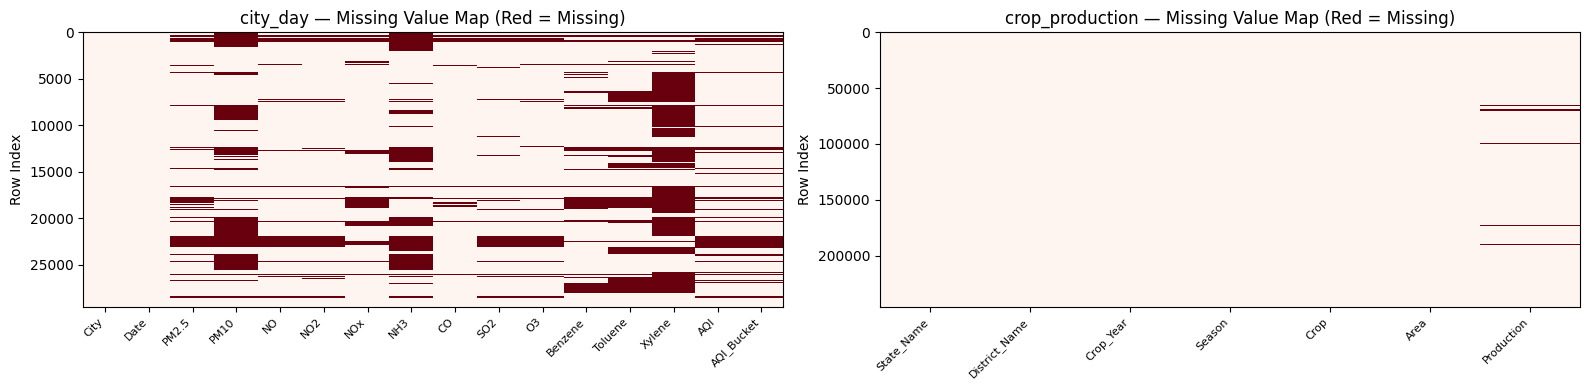

In [124]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# city_day missing pattern
axes[0].imshow(aqi.isnull(), aspect="auto", cmap="Reds", interpolation="none")
axes[0].set_xticks(range(len(aqi.columns)))
axes[0].set_xticklabels(aqi.columns, rotation=45, ha="right", fontsize=8)
axes[0].set_title("city_day — Missing Value Map (Red = Missing)")
axes[0].set_ylabel("Row Index")

# crop_production missing pattern
axes[1].imshow(crop.isnull(), aspect="auto", cmap="Reds", interpolation="none")
axes[1].set_xticks(range(len(crop.columns)))
axes[1].set_xticklabels(crop.columns, rotation=45, ha="right", fontsize=8)
axes[1].set_title("crop_production — Missing Value Map (Red = Missing)")
axes[1].set_ylabel("Row Index")

plt.tight_layout()
plt.show()

**Insight:** city_day shows vertical red stripes — entire columns like Xylene, NH3, and PM10 are missing across most rows. This means the sensors for those pollutants were simply not installed in many cities, not random data loss. crop_production's Production column shows scattered red dots — genuinely random missing entries, likely unreported harvests.

---
## Task 2 - Handling Missing Values

**Rule 1 — Drop if >50% missing:** Filling would mean inventing most of the column. → Xylene (61.32%) is dropped.

**Rule 2 — Fill, don't delete rows:** Deleting a row wastes all other valid columns just because one value is missing.

**Rule 3 — Skewness decides fill method:** |skew| > 0.5 → median (robust to extremes). |skew| ≤ 0.5 → mean.

In [125]:
print("AQI skewness:")
print(aqi.skew(numeric_only=True).round(2))
print()
print("Crop skewness:")
print(crop.skew(numeric_only=True).round(2))

AQI skewness:
PM2.5       3.37
PM10        2.05
NO          3.88
NO2         2.46
NOx         2.57
NH3         4.08
CO          8.88
SO2         4.08
O3          1.33
Benzene    21.30
Toluene    11.67
Xylene      7.89
AQI         3.40
dtype: float64

Crop skewness:
Crop_Year      0.01
Area          48.00
Production    40.74
dtype: float64


**Skewness result:** All columns are highly skewed (>0.5) → all filled with median. Xylene is skewed too but dropped instead (61% missing = fake data if filled). Crop_Year has ~0 skew but 0 missing — no action needed.

In [126]:
# drop Xylene
aqi = aqi.drop(columns=["Xylene"])
print("Xylene dropped. New shape:", aqi.shape)
print()

# fill missing values
numeric_cols = ["PM2.5","PM10","NO","NO2","NOx","NH3","CO","SO2","O3","Benzene","Toluene","AQI"]
for col in numeric_cols:
    if aqi[col].isnull().sum() == 0:
        continue
    skew_val = aqi[col].skew()
    fill_val = aqi[col].median() if abs(skew_val) > 0.5 else aqi[col].mean()
    method   = "median" if abs(skew_val) > 0.5 else "mean"
    aqi[col] = aqi[col].fillna(fill_val)
    print(f"  AQI  | {col:<8} | skew={skew_val:>6.2f} | {method} = {round(fill_val,2)}")

print()
for col in ["Area", "Production"]:
    skew_val = crop[col].skew()
    fill_val = crop[col].median() if abs(skew_val) > 0.5 else crop[col].mean()
    method   = "median" if abs(skew_val) > 0.5 else "mean"
    crop[col] = crop[col].fillna(fill_val)
    print(f"  Crop | {col:<12} | skew={skew_val:>6.2f} | {method} = {round(fill_val,2)}")

Xylene dropped. New shape: (29531, 15)

  AQI  | PM2.5    | skew=  3.37 | median = 48.57
  AQI  | PM10     | skew=  2.05 | median = 95.68
  AQI  | NO       | skew=  3.88 | median = 9.89
  AQI  | NO2      | skew=  2.46 | median = 21.69
  AQI  | NOx      | skew=  2.57 | median = 23.52
  AQI  | NH3      | skew=  4.08 | median = 15.85
  AQI  | CO       | skew=  8.88 | median = 0.89
  AQI  | SO2      | skew=  4.08 | median = 9.16
  AQI  | O3       | skew=  1.33 | median = 30.84
  AQI  | Benzene  | skew= 21.30 | median = 1.07
  AQI  | Toluene  | skew= 11.67 | median = 2.97
  AQI  | AQI      | skew=  3.40 | median = 118.0

  Crop | Area         | skew= 48.00 | median = 582.0
  Crop | Production   | skew= 40.74 | median = 729.0


In [127]:
# verify no missing values remain
print("Missing after fill - AQI  :", aqi[numeric_cols].isnull().sum().sum())
print("Missing after fill - Crop :", crop[["Area","Production"]].isnull().sum().sum())

Missing after fill - AQI  : 0
Missing after fill - Crop : 0


**Result:** Xylene dropped (61% missing). All remaining missing values filled — 0 missing in both datasets. No rows deleted.

---
## Task 3 - Fix Inconsistencies and Remove Duplicates

Check for spelling issues and trailing whitespace in key columns, then remove duplicate rows.

In [128]:
print("city_day unique cities:")
print(sorted(aqi["City"].unique()))
print()
print("crop_production unique State_Name (raw repr):")
print(sorted(crop["State_Name"].unique()))
print()
print("crop_production unique Season (raw repr):")
print(list(crop["Season"].unique()))

city_day unique cities:
['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']

crop_production unique State_Name (raw repr):
['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir ', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana ', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']

crop_production unique Season (raw repr):
['Kharif     ', 'Whole Year ', 'Autumn     ', 'Rabi       ', 'Summer     ', 'Winter     '

In [129]:
aqi["City"]        = aqi["City"].str.strip()
crop["State_Name"] = crop["State_Name"].str.strip()
crop["Season"]     = crop["Season"].str.strip()

before_aqi, before_crop = len(aqi), len(crop)
aqi  = aqi.drop_duplicates()
crop = crop.drop_duplicates()

print(f"city_day  - before: {before_aqi}, after: {len(aqi)}, dupes removed: {before_aqi - len(aqi)}")
print(f"crop_prod - before: {before_crop}, after: {len(crop)}, dupes removed: {before_crop - len(crop)}")
print()
print("State_Name after fix:", sorted(crop["State_Name"].unique()))
print()
print("Season after fix:", sorted(crop["Season"].unique()))

city_day  - before: 29531, after: 29531, dupes removed: 0
crop_prod - before: 246091, after: 246091, dupes removed: 0

State_Name after fix: ['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']

Season after fix: ['Autumn', 'Kharif', 'Rabi', 'Summer', 'Whole Year', 'Winter']


**Result:** Trailing spaces removed from State_Name ("Jammu and Kashmir ", "Telangana ") and all Season values. City names in city_day were already clean. No duplicates found in either file.

---
## Task 4 - AQI Distribution

Histogram to see where readings cluster. Boxplot to check if extremes are pulling the mean up.

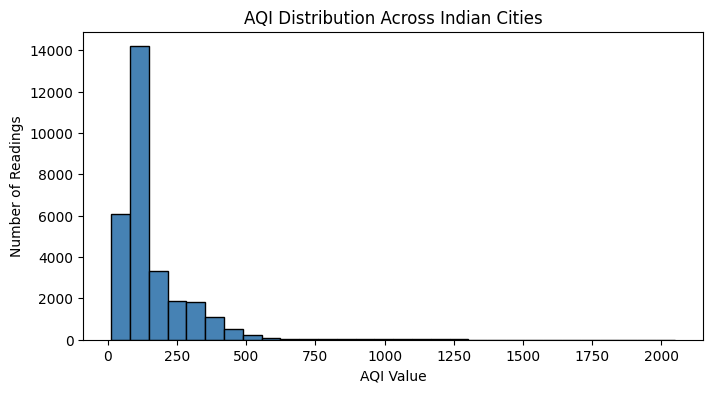

In [130]:
# histogram
plt.figure(figsize=(8, 4))
plt.hist(aqi["AQI"], bins=30, color="steelblue", edgecolor="black")
plt.title("AQI Distribution Across Indian Cities")
plt.xlabel("AQI Value")
plt.ylabel("Number of Readings")
plt.show()

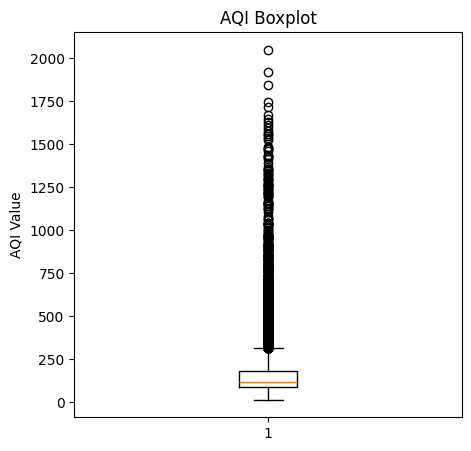

Mean AQI  : 158.78
Median AQI: 118.0


In [131]:
# boxplot
plt.figure(figsize=(5, 5))
plt.boxplot(aqi["AQI"])
plt.title("AQI Boxplot")
plt.ylabel("AQI Value")
plt.show()

print("Mean AQI  :", round(aqi["AQI"].mean(), 2))
print("Median AQI:", round(aqi["AQI"].median(), 2))

**Observation 1:** Most readings cluster between 50–300 AQI — pollution is widespread across all 26 cities.
**Observation 2:** Mean > median because extreme outliers pull it up — median is the fairer public figure.

---
## Task 5 - Handle Extreme AQI Values

AQI readings above 500 are impossible on the Indian scale. Method: **IQR capping**.

**Why IQR?** IQR only looks at the middle 50% of data (Q1–Q3), so extreme values don't inflate the threshold. Standard deviation would be stretched by the very outliers we're trying to remove.

**Why cap instead of delete?** The rest of the row (City, Date, all pollutants) is valid — only the AQI number is wrong. Capping fixes just that one value without losing the entire row.

In [132]:
# detect outliers
Q1 = aqi["AQI"].quantile(0.25)
Q3 = aqi["AQI"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Q1={Q1:.1f}  Q3={Q3:.1f}  IQR={IQR:.1f}  Upper bound={upper_bound:.1f}")
print()
extreme = aqi[aqi["AQI"] > upper_bound]
print(f"Extreme readings found: {len(extreme)}")
print(extreme[["City","Date","AQI"]].sort_values("AQI", ascending=False).head(10).to_string())

Q1=88.0  Q3=179.0  IQR=91.0  Upper bound=315.5

Extreme readings found: 3192
           City        Date     AQI
1145  Ahmedabad  2018-02-19  2049.0
1136  Ahmedabad  2018-02-10  1917.0
560   Ahmedabad  2016-07-14  1842.0
1048  Ahmedabad  2017-11-14  1747.0
1463  Ahmedabad  2019-01-03  1719.0
1417  Ahmedabad  2018-11-18  1672.0
1420  Ahmedabad  2018-11-21  1646.0
1407  Ahmedabad  2018-11-08  1630.0
1127  Ahmedabad  2018-02-01  1613.0
1746  Ahmedabad  2019-10-13  1595.0


In [133]:
# cap outliers
aqi_before    = aqi["AQI"].copy()
aqi["AQI"]    = aqi["AQI"].clip(upper=upper_bound)

print(f"Max AQI  before: {aqi_before.max():.1f}  ->  after: {aqi['AQI'].max():.1f}")
print(f"Mean AQI before: {aqi_before.mean():.1f}  ->  after: {aqi['AQI'].mean():.1f}")

Max AQI  before: 2049.0  ->  after: 315.5
Mean AQI before: 158.8  ->  after: 145.0


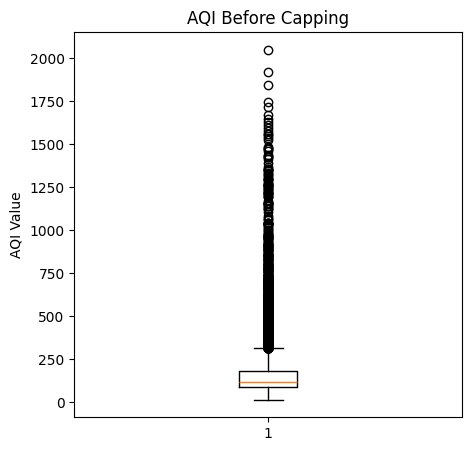

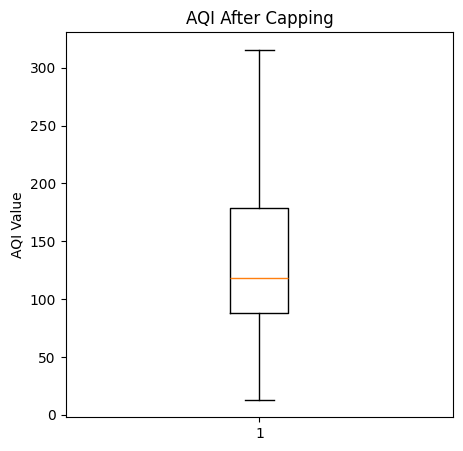

In [134]:
# before vs after
plt.figure(figsize=(5, 5))
plt.boxplot(aqi_before.dropna())
plt.title("AQI Before Capping")
plt.ylabel("AQI Value")
plt.show()

plt.figure(figsize=(5, 5))
plt.boxplot(aqi["AQI"])
plt.title("AQI After Capping")
plt.ylabel("AQI Value")
plt.show()

**Result:** 3,192 readings above upper bound (315.5) were capped — highest was 2,049 (Ahmedabad). No rows deleted. Max AQI dropped from 2,049 → 315.5, mean from 158.8 → 145.0. The before/after boxplots confirm the treatment worked.

---
## Conclusion

**Task 1:** Found missing values across all 13 columns in city_day (Xylene 61%), AQI max of 2,049, and whitespace issues in crop_production.
**Task 2:** Dropped Xylene (>50% missing). Filled remaining columns using skewness rule — all skewed, so all used median. No rows deleted.
**Task 3:** Stripped trailing spaces from State_Name and Season in crop_production. City names already clean. No duplicates in either file.
**Task 4:** AQI clusters between 50–300. Mean pulled above median by extreme values.
**Task 5:** Capped 3,192 impossible AQI readings at IQR upper bound (315.5). Max dropped from 2,049 to 315.5.

Both datasets are now clean and ready for modelling.